Want to test if there is a relationship between change in delay for a route and change in ridership over time

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from bus_delay_time_analysis.routes_preprocessing import *

In [3]:
# 2023 delay, want to combine sept-dec
for month in ["Aug-Sept 2018", "Oct-Dec 2018"]:
    filename = f'./datasets/MBTA_Bus_Arrival_Departure_Times_2018/MBTA Bus Arrival Departure {month}.csv'
    df = pd.read_csv(filename)
    if month == "Aug-Sept 2018":
        df_2018 = df
    else:
        df_2018 = pd.concat([df_2018, df])

In [ ]:
average_delay_per_route_2018 = preprocess_routes(df_2018)

In [ ]:
# 2024 delay, want to combine sept-dec
for month in ["09", "10", "11", "12"]:
    filename = f'./datasets/MBTA_Bus_Arrival_Departure_Times_2024/MBTA-Bus-Arrival-Departure-Times_2024-{month}.csv'
    df = pd.read_csv(filename)
    if month == "09":
        df_2024 = df
    else:
        df_2024 = pd.concat([df_2024, df])

In [ ]:
average_delay_per_route_2024 = preprocess_routes(df_2024)

c:\Users\Michael\Desktop\BU\2025-Spring\CS 506\Final_Project\MBTA-bus-inequity-analysis\bus_delay_time_analysis\routes_preprocessing.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  routes_df['time_difference'] = pd.to_datetime(routes_df['actual']) - pd.to_datetime(routes_df['scheduled'])
c:\Users\Michael\Desktop\BU\2025-Spring\CS 506\Final_Project\MBTA-bus-inequity-analysis\bus_delay_time_analysis\routes_preprocessing.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  routes_df['delay_seconds'] = rout

In [ ]:
delay_comparison = pd.merge(
    average_delay_per_route_2018,
    average_delay_per_route_2024,
    on='route_id',
    suffixes=('_2018', '_2024')
)

delay_comparison['delay_change'] = (
    delay_comparison['delay_seconds_2024'] - delay_comparison['delay_seconds_2018']
)


In [ ]:
filename_2018_ridership = './datasets/MBTA_Bus_Ridership_by_Trip_Season_Route_Line_and_Stop/MBTA_Bus_Ridership_by_Trip_Season_Route_Line_and_Stop_Fall_2018.csv'
filename_2024_ridership = './datasets/MBTA_Bus_Ridership_by_Trip_Season_Route_Line_and_Stop/MBTA_Bus_Ridership_by_Trip_Season_Route_Line_and_Stop_Fall_2024.csv'


In [ ]:
# linear regression between average bus delay over a season and change in ridership from year to year

df_2018_ridership = pd.read_csv(filename_2018_ridership)
df_2024_ridership = pd.read_csv(filename_2024_ridership)

df_2018_ridership = df_2018_ridership[df_2018_ridership['day_type_name'] == 'weekday']
df_2024_ridership = df_2024_ridership[df_2024_ridership['day_type_name'] == 'weekday']

df_2018_ridership = df_2018_ridership.groupby('route_id')['boardings'].sum().reset_index()
df_2024_ridership = df_2024_ridership.groupby('route_id')['boardings'].sum().reset_index()

df_2018_ridership.head()

ridership_comparison = pd.merge(
    df_2018_ridership,
    df_2024_ridership,
    on='route_id',
    suffixes=('_2018', '_2024')
)

ridership_comparison['boardings_change'] = (
    ridership_comparison['boardings_2024'] - ridership_comparison['boardings_2018']
)



# For each bus route, I need to sum the total number of boardings. This will be the average ridership per day in both directions
# I need to do this for two years, 2023 and 2024, and use this to find change in ridership
# Fall runs sep - dec, creating a collated file for all delays in 2023
# Sanity check with values anthony found for total mbta ridership
# Then I need to find average bus delay for each route in 2023. 
# Create a table with route_name, 2023_delay, delta_ridership
  # This will be the data I use to plot the linear regression



C:\Users\Michael\AppData\Local\Temp\ipykernel_9264\167978679.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2023_ridership = pd.read_csv(filename_2023_ridership)
C:\Users\Michael\AppData\Local\Temp\ipykernel_9264\167978679.py:4: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2024_ridership = pd.read_csv(filename_2024_ridership)


In [27]:
ridership_comparison.head()
print(ridership_comparison['route_id'].tolist())


[1, 7, 8, 9, 10, 11, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 43, 44, 45, 47, 50, 51, 52, 55, 57, 59, 60, 61, 62, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75, 76, 77, 78, 80, 83, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 99, 100, 101, 104, 105, 106, 108, 109, 110, 111, 112, 114, 116, 117, 119, 120, 121, 131, 132, 134, 137, 171, 201, 202, 210, 211, 215, 216, 217, 220, 222, 225, 226, 230, 236, 238, 240, 426, 428, 429, 430, 435, 436, 439, 441, 442, 450, 451, 455, 456, 501, 504, 505, 553, 554, 556, 558, 708, 712, 713, 741, 742, 743, 746, 747, 749, 751, '30', '31', '32', '33', '34', '34E', '35', '350', '351', '354']


In [ ]:
# For some reason route_id is an int for random values in the ridership data, have to convert to str
ridership_comparison['route_id'] = ridership_comparison['route_id'].astype(str)

merged_data = pd.merge(delay_comparison, on='route_id', right=ridership_comparison, how='inner')
merged_data.head()

print(merged_data.shape)

(117, 7)


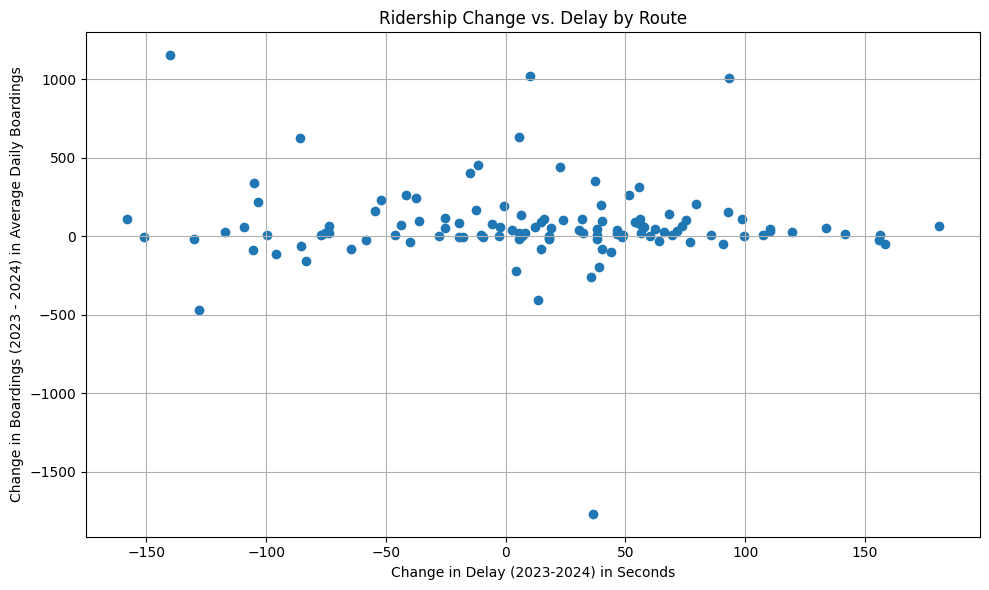

In [ ]:
import matplotlib.pyplot as plt

# Assuming your DataFrame is called df
plt.figure(figsize=(10, 6))
plt.scatter(merged_data['delay_change'], merged_data['boardings_change'])

plt.xlabel('Change in Delay (2018-2024) in Seconds')
plt.ylabel('Change in Boardings (2018 - 2024) in Average Daily Boardings')
plt.title('Ridership Change vs. Delay by Route')
plt.grid(True)
plt.tight_layout()
plt.show()


Regression equation: y = -0.264x + 68.491
R² (coefficient of determination): 0.0046


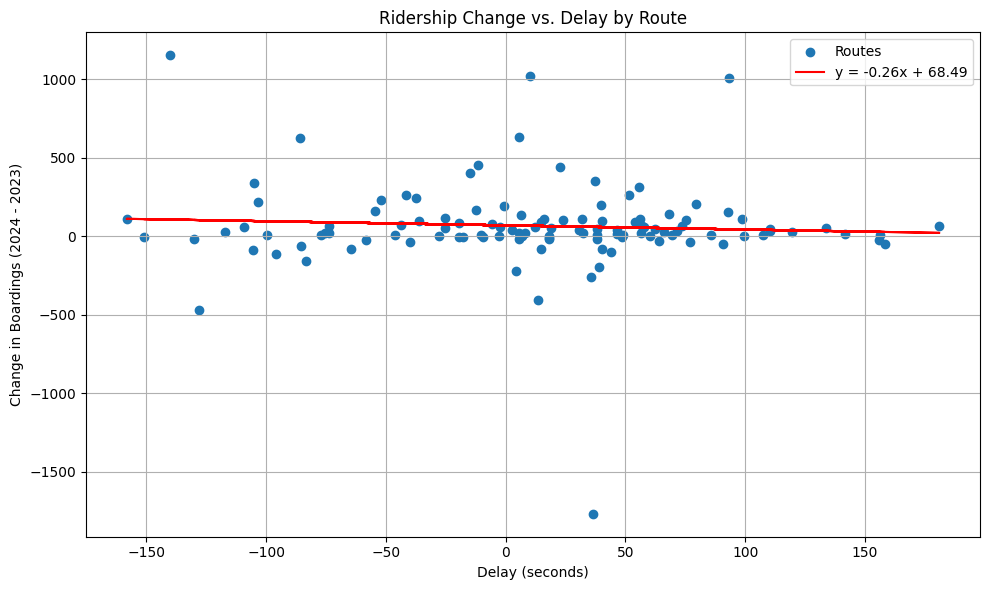

In [30]:
from scipy.stats import linregress
import matplotlib.pyplot as plt

x = merged_data['delay_change']
y = merged_data['boardings_change']

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Regression line equation and R²
print(f"Regression equation: y = {slope:.3f}x + {intercept:.3f}")
print(f"R² (coefficient of determination): {r_value**2:.4f}")

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Routes')
plt.plot(x, slope * x + intercept, color='red', label=f'y = {slope:.2f}x + {intercept:.2f}')
plt.xlabel('Delay (seconds)')
plt.ylabel('Change in Boardings (2024 - 2023)')
plt.title('Ridership Change vs. Delay by Route')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
